# Evaluate neural network MOA models

This notebook compares the test-set precision-recall performance of the saved `pre-QC final`, `post-QC final`, and shuffled-control MLP models.

In [ ]:
import pathlib
import sys

import joblib
import numpy as np
import pandas as pd
from iPython.display import display
from pycytominer.cyto_utils import infer_cp_features
from sklearn.metrics import average_precision_score
from sklearn.preprocessing import MultiLabelBinarizer

sys.path.append(("../figure_5/utils"))
import eval_neural_net_models as eval_nn


In [ ]:
# Output and input paths
figure_dir = pathlib.Path("figures")
figure_dir.mkdir(exist_ok=True)

model_dir = pathlib.Path("models")
input_dir = pathlib.Path(
    "/home/jenna/mnt/bandicoot/LINCS_data/processed_profiles/single_cell_profiles"
)
train_targets_path = pathlib.Path(
    "./ground_truth_test_train_splits/train_lvl4_data_targets.csv.gz"
)
test_targets_path = pathlib.Path(
    "./ground_truth_test_train_splits/test_lvl4_data_targets.csv.gz"
)


In [ ]:
# Load targets and prepare test sets
train_targets_df = pd.read_csv(train_targets_path).copy()
test_targets_df = pd.read_csv(test_targets_path).copy()

train_targets_df["moa_list"] = eval_nn.split_moas(train_targets_df["Metadata_moa"])
test_targets_df["moa_list"] = eval_nn.split_moas(test_targets_df["Metadata_moa"])

print("Ground truth splits loaded!")


Ground truth splits loaded!


In [ ]:
# Fit the MultiLabelBinarizer on the training MOA lists to establish the label space
mlb = MultiLabelBinarizer()
mlb.fit(train_targets_df["moa_list"])

# Get the set of test compounds for filtering profiles
test_compounds = set(test_targets_df["pert_iname"].unique())

# Load profiles, infer features, and build test frames for pre- and post-QC data
pre_qc_df = pd.read_parquet(input_dir / "whole_batch_pre_qc_cpd_replicates.parquet")
post_qc_df = pd.read_parquet(input_dir / "whole_batch_post_qc_cpd_replicates.parquet")

pre_feature_columns = infer_cp_features(pre_qc_df, metadata=False)
post_feature_columns = infer_cp_features(post_qc_df, metadata=False)

pre_test_df, X_pre_test = eval_nn.build_test_frame(
    profiles_df=pre_qc_df,
    test_compounds=test_compounds,
    feature_columns=pre_feature_columns,
)
post_test_df, X_post_test = eval_nn.build_test_frame(
    profiles_df=post_qc_df,
    test_compounds=test_compounds,
    feature_columns=post_feature_columns,
)

# Transform MOA lists to binary indicator arrays for evaluation
y_pre_test = mlb.transform(pre_test_df["moa_list"])
y_post_test = mlb.transform(post_test_df["moa_list"])

# Print shapes and label space info for verification
print("Pre-QC test shape:", X_pre_test.shape, y_pre_test.shape)
print("Post-QC test shape:", X_post_test.shape, y_post_test.shape)
print("MOA classes:", len(mlb.classes_))


Pre-QC test shape: (10788, 795) (10788, 439)
Post-QC test shape: (10788, 855) (10788, 439)
MOA classes: 439


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/sklearn/preprocessing/_label.py:1007: UserWarning: unknown class(es) ['FXR agonist', 'calpain inhibitor', 'caspase inhibitor', 'cysteine protease inhibitor', 'gastrin inhibitor', 'lipid peroxidase inhibitor', 'oxidizing agent', 'peptidase inhibitor', 'progestogen hormone', 'protease inhibitor', 'serine protease inhibitor'] will be ignored


In [ ]:
# Load saved models and define evaluation inputs
model_inputs = {
    "pre-QC final": (
        joblib.load(model_dir / "pre_qc_final_mlp.joblib"),
        X_pre_test,
        y_pre_test,
        "#B24C63",
    ),
    "post-QC final": (
        joblib.load(model_dir / "post_qc_final_mlp.joblib"),
        X_post_test,
        y_post_test,
        "#2A7F62",
    ),
    "pre-QC shuffled": (
        joblib.load(model_dir / "pre_qc_shuffled_mlp.joblib"),
        X_pre_test,
        y_pre_test,
        "#D8A047",
    ),
    "post-QC shuffled": (
        joblib.load(model_dir / "post_qc_shuffled_mlp.joblib"),
        X_post_test,
        y_post_test,
        "#7A7A7A",
    ),
}

list(model_inputs.keys())


['pre-QC final', 'post-QC final', 'pre-QC shuffled', 'post-QC shuffled']

In [ ]:
# Get predicted scores for each model and store them with true labels and colors
model_scores = {}
palette = {}

for label, (model, X_eval, y_eval, color) in model_inputs.items():
    y_score = eval_nn.get_positive_class_scores(model, X_eval).to_numpy()
    model_scores[label] = {
        "y_true": y_eval,
        "y_score": y_score,
        "color": color,
    }
    palette[label] = color


## Per-class AUCPR across all MOAs

This scatterplot compares one-vs-rest AUCPR for every evaluable MOA in the final `pre-QC` and `post-QC` models using test-set predictions. It gives each class equal weight, which is a better check of broad QC improvement than the pooled PR curve alone. Point size is proportional to the number of test compounds for that MOA.

In [ ]:
pre_final = model_scores["pre-QC final"]
post_final = model_scores["post-QC final"]

if not np.array_equal(pre_final["y_true"], post_final["y_true"]):
    raise ValueError(
        "Pre-QC and post-QC labels are not aligned; cannot compare AUPR per class.",
    )

per_class_aucpr_rows = []
y_true_all = pre_final["y_true"]

for class_idx, moa in enumerate(mlb.classes_):
    y_true_class = y_true_all[:, class_idx]
    test_positive_examples = int(y_true_class.sum())
    negative_examples = int(len(y_true_class) - test_positive_examples)

    if test_positive_examples == 0 or negative_examples == 0:
        continue

    pre_aucpr = average_precision_score(
        y_true_class, pre_final["y_score"][:, class_idx]
    )
    post_aucpr = average_precision_score(
        y_true_class, post_final["y_score"][:, class_idx]
    )

    prevalence = test_positive_examples / len(y_true_class)

    per_class_aucpr_rows.append(
        {
            "moa": moa,
            "pre_qc_aucpr": pre_aucpr,
            "post_qc_aucpr": post_aucpr,
            "delta_aucpr": post_aucpr - pre_aucpr,
            "test_positive_examples": test_positive_examples,
            "prevalence": prevalence,
            "pre_qc_lift": pre_aucpr / prevalence,
            "post_qc_lift": post_aucpr / prevalence,
            "delta_lift": (post_aucpr / prevalence) - (pre_aucpr / prevalence),
        }
    )

per_class_aucpr_summary = (
    pd.DataFrame(per_class_aucpr_rows)
    .sort_values("delta_aucpr", ascending=False)
    .reset_index(drop=True)
)
per_class_aucpr_summary["combined_aucpr"] = (
    per_class_aucpr_summary["pre_qc_aucpr"] + per_class_aucpr_summary["post_qc_aucpr"]
)

held_out_moa_compound_counts = eval_nn.build_held_out_moa_compound_counts(test_targets_df)
per_class_aucpr_summary = per_class_aucpr_summary.merge(
    held_out_moa_compound_counts,
    on="moa",
    how="left",
)

moa_failed_fraction_summary = eval_nn.build_moa_failed_fraction_summary(
    post_qc_df=post_qc_df,
    test_compounds=test_compounds,
)
per_class_aucpr_summary = per_class_aucpr_summary.merge(
    moa_failed_fraction_summary,
    on="moa",
    how="left",
)
per_class_aucpr_summary.to_csv(
    figure_dir / "aucpr_scatter_pre_vs_post_qc_all_moas_summary.csv", index=False
)

per_class_aucpr_output_path = figure_dir / "aucpr_scatter_pre_vs_post_qc_all_moas.png"
aucpr_scatter_plot = eval_nn.make_aucpr_scatter_plot(
    per_class_aucpr_summary=per_class_aucpr_summary,
    output_path=per_class_aucpr_output_path,
),

display(aucpr_scatter_plot)


Data-driven QC threshold (0.5 * std): 0.0238
MOA improvement status counts:
Improved after QC: 9 MOAs
No change: 197 MOAs
Declined after QC: 16 MOAs
Top 6 MOAs by combined AUCPR:
proteasome inhibitor: x=0.5411, y=0.8308, Improved after QC
mTOR inhibitor: x=0.7188, y=0.7975, Improved after QC
inositol monophosphatase inhibitor: x=0.5841, y=0.7194, Improved after QC
MEK inhibitor: x=0.7667, y=0.6583, Declined after QC
dehydrogenase inhibitor: x=0.6911, y=0.6448, Declined after QC
glucocorticoid receptor agonist: x=0.6052, y=0.5841, No change


(<plotnine.ggplot.ggplot object at 0x7537e37e7c10>,)

Data-driven QC threshold (0.5 * std): 0.0238

Top 4 increases:
                      moa  delta_aucpr
     proteasome inhibitor     0.289707
           HDAC inhibitor     0.287191
retinoid receptor agonist     0.174144
           EGFR inhibitor     0.159148

Top 4 decreases:
                  moa  delta_aucpr
        PLK inhibitor    -0.246005
       XIAP inhibitor    -0.203048
        HSP inhibitor    -0.194875
calcineurin inhibitor    -0.149106


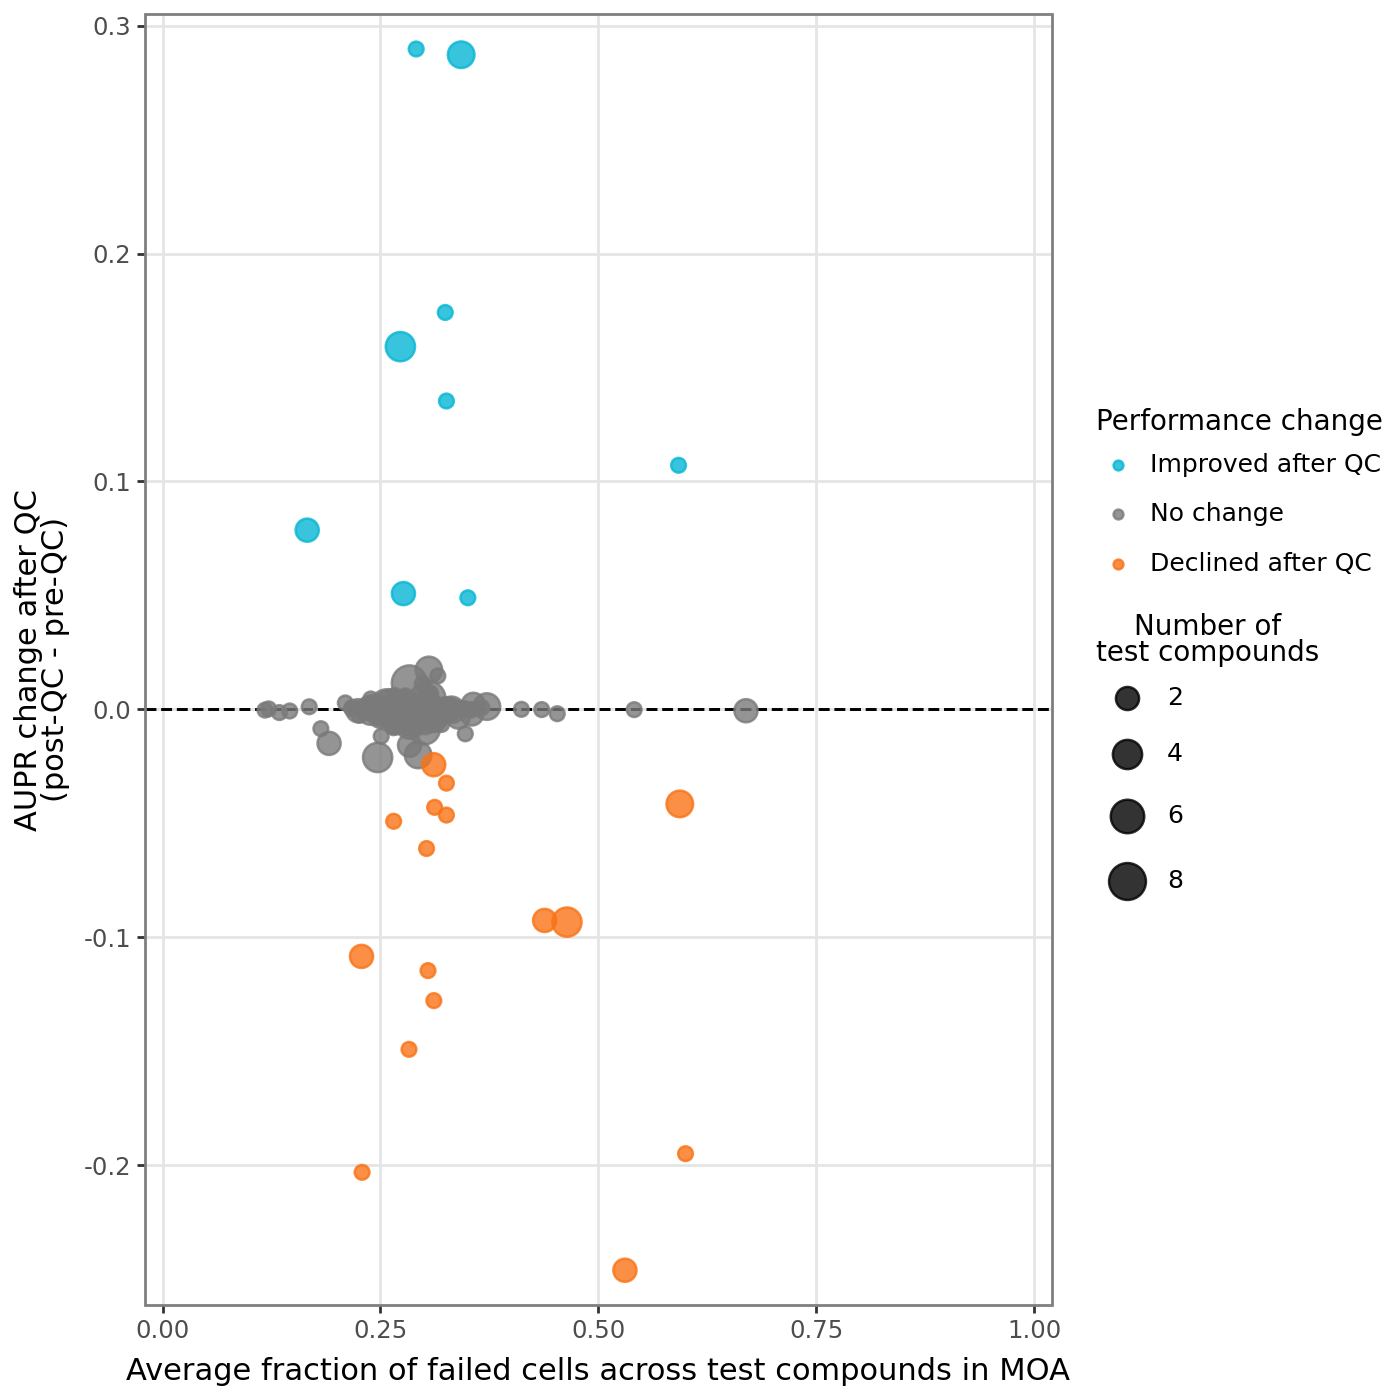

In [ ]:
failed_fraction_aucpr_output_path = (
    figure_dir / "aucpr_change_vs_failed_fraction_all_moas.png"
)
failed_fraction_aucpr_plot = eval_nn.make_aucpr_change_vs_failed_fraction_plot(
    per_class_aucpr_summary, failed_fraction_aucpr_output_path
)

display(failed_fraction_aucpr_plot)


In [ ]:
# Define a no-change threshold using the same half-standard-deviation rule
delta_std = per_class_aucpr_summary["delta_aucpr"].std()
noise_threshold = 0.5 * delta_std
print(f"Data-driven QC threshold (0.5 * std): {noise_threshold:.4f}")

# Get MOAs that declined, improved, or showed no meaningful change after QC
per_class_aucpr_summary = per_class_aucpr_summary.copy()
per_class_aucpr_summary["improvement_status"] = np.where(
    per_class_aucpr_summary["delta_aucpr"] > noise_threshold,
    "Improved after QC",
    np.where(
        per_class_aucpr_summary["delta_aucpr"] < -noise_threshold,
        "Declined after QC",
        "No change",
    ),
)

declined_moas = per_class_aucpr_summary[
    per_class_aucpr_summary["improvement_status"] == "Declined after QC"
]["moa"].tolist()
improved_moas = per_class_aucpr_summary[
    per_class_aucpr_summary["improvement_status"] == "Improved after QC"
]["moa"].tolist()
no_change_moas = per_class_aucpr_summary[
    per_class_aucpr_summary["improvement_status"] == "No change"
]["moa"].tolist()

# Filter failed fraction summaries
declined_summary = moa_failed_fraction_summary[
    moa_failed_fraction_summary["moa"].isin(declined_moas)
].copy()

improved_summary = moa_failed_fraction_summary[
    moa_failed_fraction_summary["moa"].isin(improved_moas)
].copy()

no_change_summary = moa_failed_fraction_summary[
    moa_failed_fraction_summary["moa"].isin(no_change_moas)
].copy()

# Summary stats
print("=== FAILED FRACTION SUMMARY ===\n")

print("Declined MOAs:")
print(f"  Mean avg compound failed fraction: {declined_summary['avg_compound_failed_fraction'].mean():.4f}")
print(f"  Number of MOAs: {declined_summary['moa'].nunique()}")

print("\nImproved MOAs:")
print(f"  Mean avg compound failed fraction: {improved_summary['avg_compound_failed_fraction'].mean():.4f}")
print(f"  Number of MOAs: {improved_summary['moa'].nunique()}")

print("\nNo-change MOAs:")
print(f"  Mean avg compound failed fraction: {no_change_summary['avg_compound_failed_fraction'].mean():.4f}")
print(f"  Number of MOAs: {no_change_summary['moa'].nunique()}")


Data-driven QC threshold (0.5 * std): 0.0238
=== FAILED FRACTION SUMMARY ===

Declined MOAs:
  Mean avg compound failed fraction: 0.3641
  Number of MOAs: 16

Improved MOAs:
  Mean avg compound failed fraction: 0.3268
  Number of MOAs: 9

No-change MOAs:
  Mean avg compound failed fraction: 0.2893
  Number of MOAs: 197


In [ ]:
# Compound-level follow-up: identify compounds with the highest failed-cell fraction
compound_failed_fraction_df = post_qc_df.loc[
    post_qc_df["pert_iname"].isin(test_compounds),
    [
        "pert_iname",
        "Metadata_moa",
        "Metadata_dose_recode",
        "Metadata_sc_count_failed_qc",
        "Metadata_sc_count_passed_qc",
    ],
].copy()

compound_failed_fraction_df["Metadata_sc_count_failed_qc"] = (
    compound_failed_fraction_df["Metadata_sc_count_failed_qc"].fillna(0)
)
compound_failed_fraction_df["Metadata_sc_count_passed_qc"] = (
    compound_failed_fraction_df["Metadata_sc_count_passed_qc"].fillna(0)
)

compound_failed_fraction_df["total_cells"] = (
    compound_failed_fraction_df["Metadata_sc_count_failed_qc"]
    + compound_failed_fraction_df["Metadata_sc_count_passed_qc"]
)

compound_failed_fraction_df = compound_failed_fraction_df.loc[
    compound_failed_fraction_df["total_cells"] > 0
].copy()

compound_failed_fraction_df["compound_failed_fraction"] = (
    compound_failed_fraction_df["Metadata_sc_count_failed_qc"]
    / compound_failed_fraction_df["total_cells"]
)

# Average failed fraction across all wells for the same compound, dose, and MoA
compound_failed_fraction_df = (
    compound_failed_fraction_df
    .groupby(
        [
            "pert_iname",
            "Metadata_moa",
            "Metadata_dose_recode",
        ],
        as_index=False,
    )
    .agg(
        compound_failed_fraction=("compound_failed_fraction", "mean"),
    )
)

compound_failed_fraction_df["moa_list"] = eval_nn.split_moas(
    compound_failed_fraction_df["Metadata_moa"]
)

compound_failed_fraction_df = compound_failed_fraction_df.explode("moa_list").rename(
    columns={"moa_list": "moa", "pert_iname": "compound"}
)

compound_failed_fraction_df = compound_failed_fraction_df.merge(
    per_class_aucpr_summary[["moa", "delta_aucpr", "improvement_status"]],
    on="moa",
    how="left",
)

compound_failed_fraction_df = compound_failed_fraction_df.sort_values(
    "compound_failed_fraction", ascending=False
).reset_index(drop=True)

# Top 10 compound-dose combinations with highest failed-cell fraction
top_compounds = compound_failed_fraction_df.head(10).copy()

# Print number of top 10 with declined MoA performance after QC
n_declined = top_compounds[
    top_compounds["improvement_status"] == "Declined after QC"
].shape[0]

print(
    f"{n_declined}/{len(top_compounds)} of the top 10 compound-dose combinations by failed-cell fraction "
    "had a decline in MoA performance after QC."
)

# Print top 10 compounds
top_compounds[
    [
        "compound",
        "moa",
        "Metadata_dose_recode",
        "compound_failed_fraction",
        "delta_aucpr",
        "improvement_status",
    ]
]


3/10 of the top 10 compound-dose combinations by failed-cell fraction had a decline in MoA performance after QC.


,compound,moa,Metadata_dose_recode,compound_failed_fraction,delta_aucpr,improvement_status
0,midostaurin,KIT inhibitor,4,0.890813,-0.000180,No change
1,midostaurin,FLT3 inhibitor,4,0.890813,-0.092557,Declined after QC
2,midostaurin,PKC inhibitor,4,0.890813,0.000140,No change
3,cabazitaxel,microtubule inhibitor,6,0.880072,-0.000571,No change
4,cabazitaxel,microtubule inhibitor,5,0.866370,-0.000571,No change
5,sunitinib,PLK inhibitor,6,0.854518,-0.246005,Declined after QC
6,cabazitaxel,microtubule inhibitor,4,0.854269,-0.000571,No change
7,aphidicolin,RNA synthesis inhibitor,5,0.848033,0.000052,No change
8,alisertib,Aurora kinase inhibitor,4,0.846716,0.107100,Improved after QC
9,tas-103,topoisomerase inhibitor,2,0.845519,-0.093294,Declined after QC


## PR curves for selected MOAs

These panels show one-vs-rest PR curves for top or bottom performing MoAs after QC, with each MOA plotted side by side.

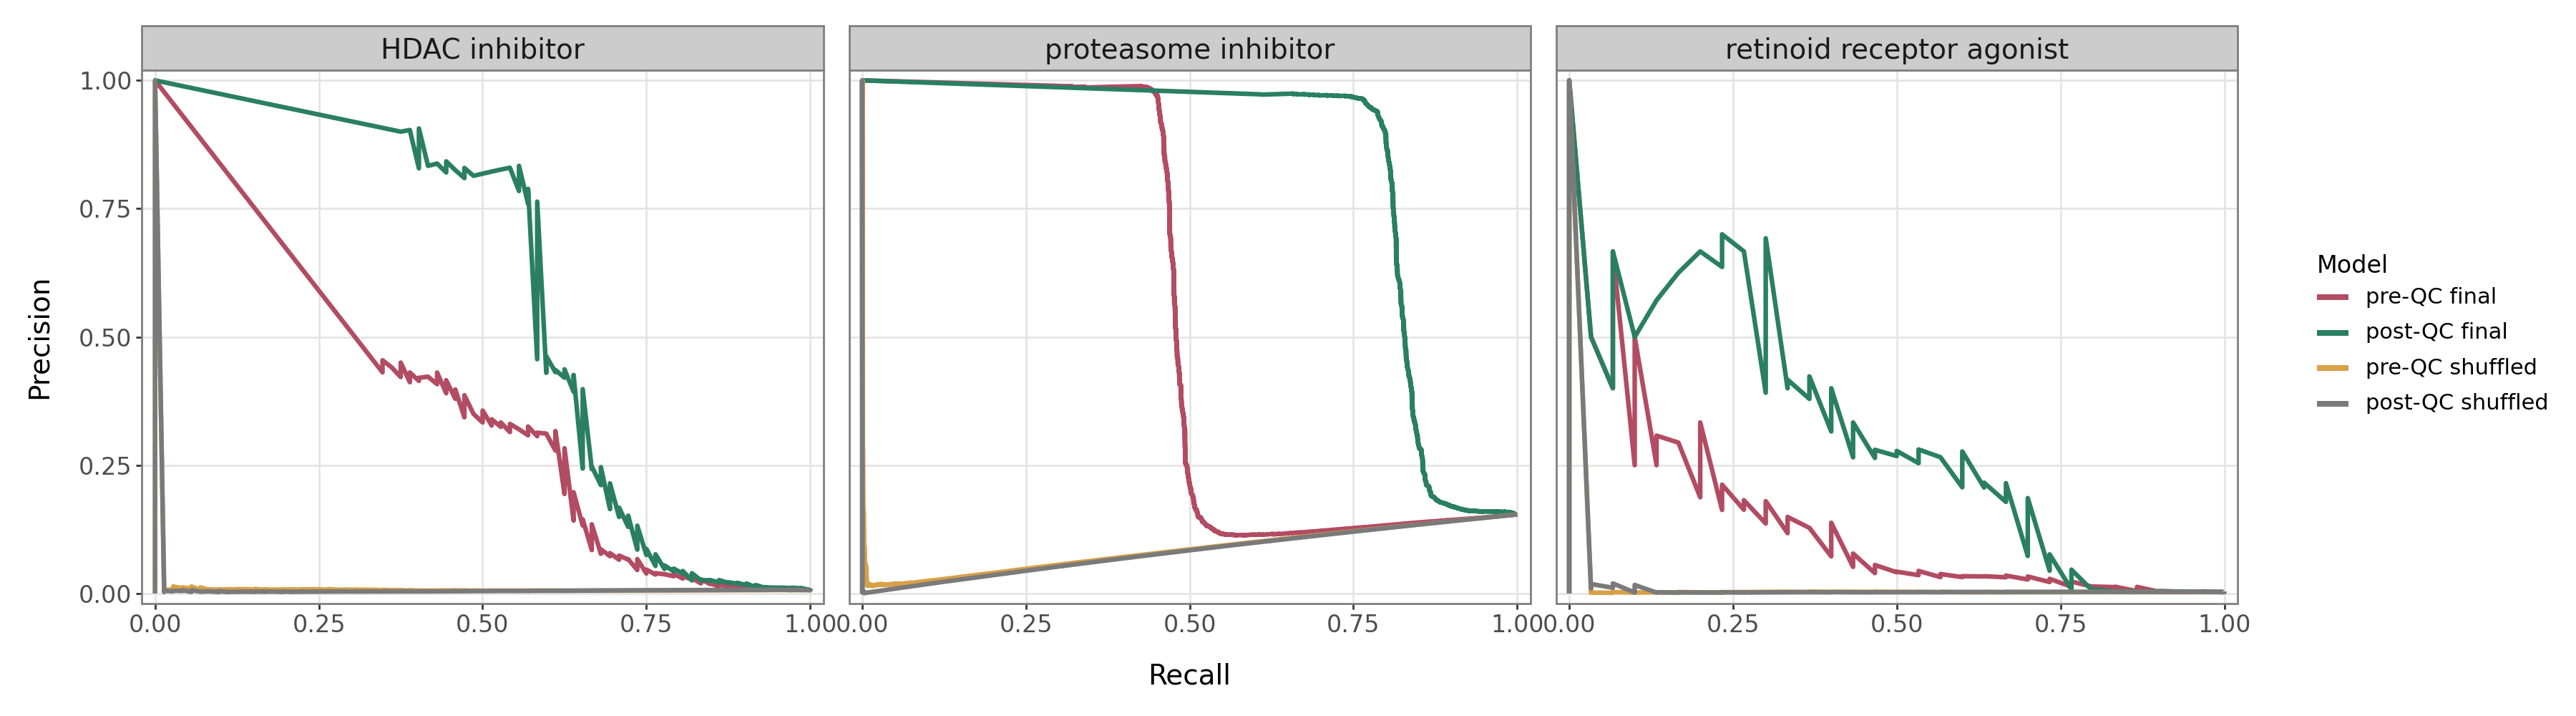

In [ ]:
# Get the top 3 MOAs with largest improvement (delta_aucpr) post-QC
top_improved_moas = per_class_aucpr_summary.nlargest(3, "delta_aucpr")["moa"].tolist()

selected_curve_df, selected_moa_summary = eval_nn.build_selected_moa_pr_curve_df(
    selected_moas=top_improved_moas,
    mlb=mlb,
    model_scores=model_scores,
)
selected_output_path = figure_dir / "pr_curve_top_improved_moas.png"

selected_moa_plot = eval_nn.make_pr_curve_plot(
    curve_df=selected_curve_df,
    config={
        "palette": palette,
        "facet_formula": "~moa",
        "figure_size": (18, 5),
    },
    output_path=selected_output_path,
)

display(selected_moa_plot)


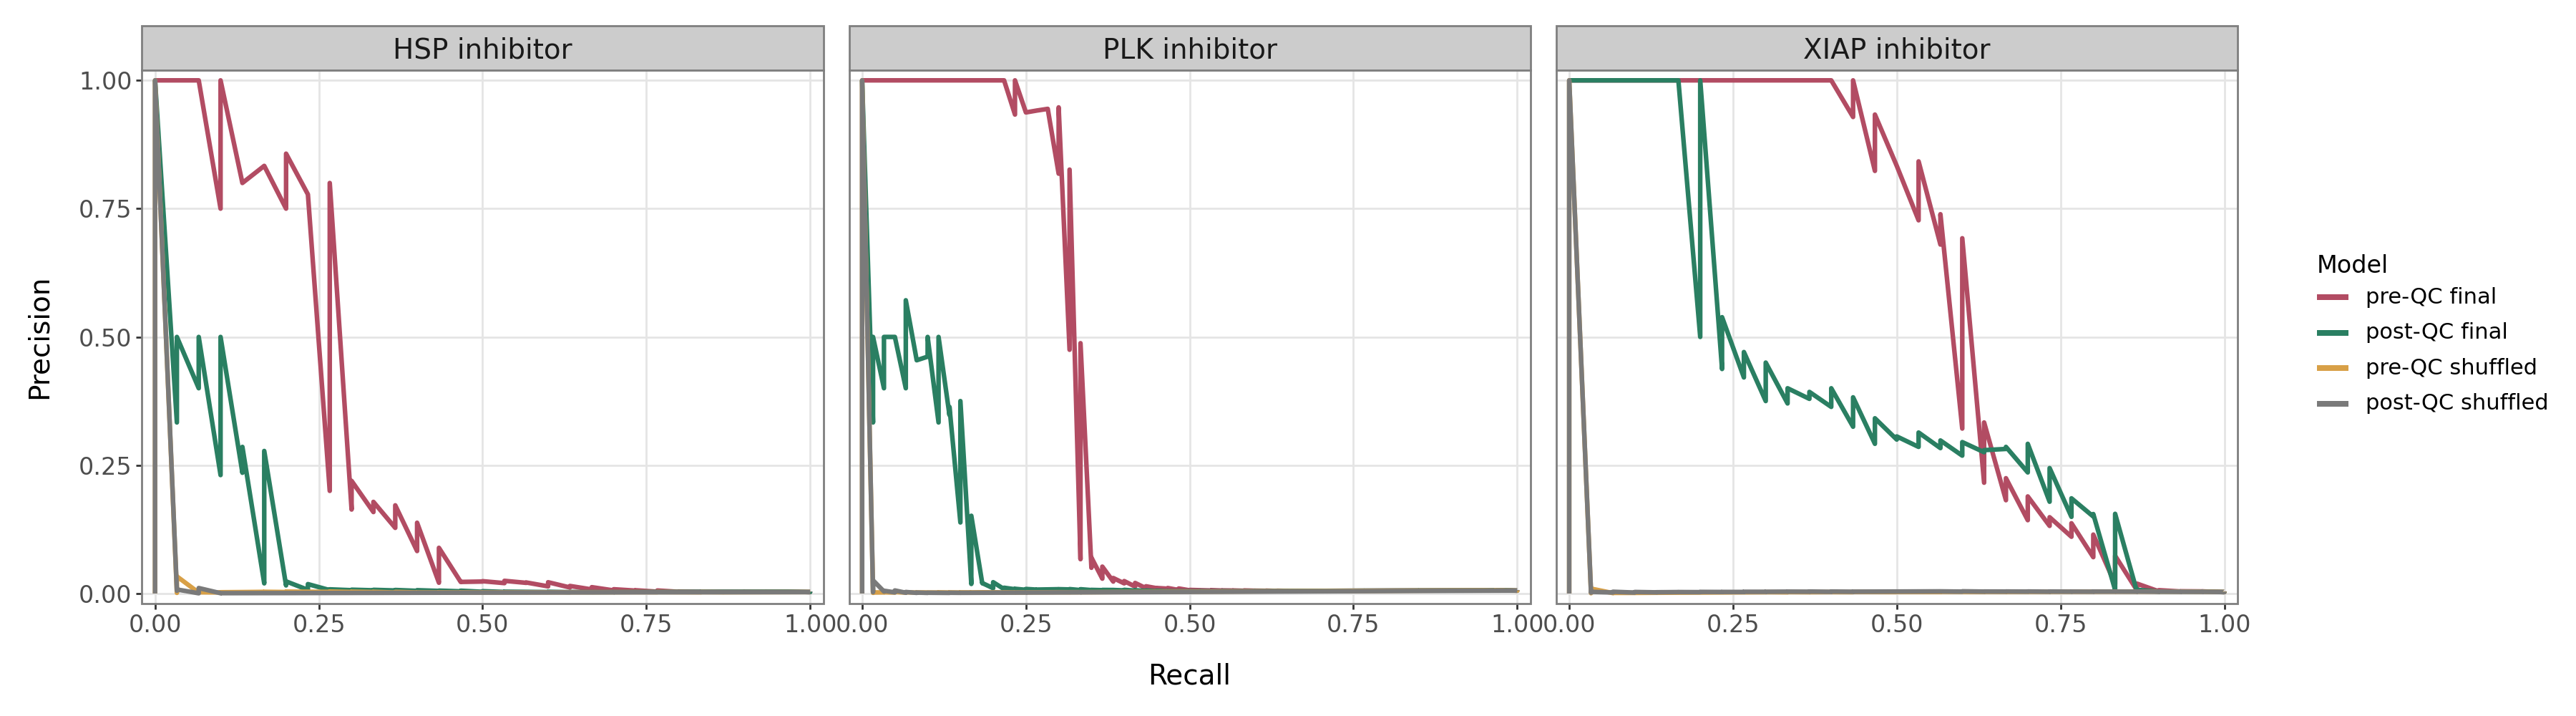

In [ ]:
# Get the top 3 MOAs with lowest improvement (delta_aucpr) post-QC
top_poor_performing_moas = per_class_aucpr_summary.nsmallest(3, "delta_aucpr")["moa"].tolist()

selected_curve_df, selected_moa_summary = eval_nn.build_selected_moa_pr_curve_df(
    selected_moas=top_poor_performing_moas,
    mlb=mlb,
    model_scores=model_scores,
)
selected_output_path = figure_dir / "pr_curve_poor_performing_moas.png"

selected_moa_plot = eval_nn.make_pr_curve_plot(
    curve_df=selected_curve_df,
    config={
        "palette": palette,
        "facet_formula": "~moa",
        "figure_size": (18, 5),
    },
    output_path=selected_output_path,
)

display(selected_moa_plot)
